# Error analysis by day type

One-off analysis: break down the walk-forward backtest's aggregate result (model MAE 1286 MW vs. seasonal-naive MAE 3654 MW vs. RTE's own forecast MAE 1298 MW, over 347 backtest days) by day type, to see *where* and *why* errors happen rather than reporting a single number. See `docs/decisions/0005-error-analysis-by-day-type.md` for how each category is defined and why.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_parquet("../data/processed/backtest_results.parquet")
results = results.set_index("date_heure").sort_index()

dataset = pd.read_parquet("../data/processed/dataset.parquet")
dataset = dataset.set_index("date_heure").sort_index()

context_cols = [
    "est_ferie",
    "vacances_zone_a",
    "vacances_zone_b",
    "vacances_zone_c",
    "temperature_nationale",
]
df = results.join(dataset[context_cols], how="left")

print(len(df), "rows")
print(df[context_cols].isna().sum())

8303 rows
est_ferie                0
vacances_zone_a          0
vacances_zone_b          0
vacances_zone_c          0
temperature_nationale    0
dtype: int64


In [2]:
local_index = df.index.tz_convert("Europe/Paris")
local_day = local_index.normalize()

daily_temp = (
    dataset["temperature_nationale"]
    .groupby(dataset.index.tz_convert("Europe/Paris").normalize())
    .mean()
)

df["is_weekend"] = local_index.dayofweek >= 5
df["is_holiday"] = df["est_ferie"]
df["is_school_holiday"] = df["vacances_zone_a"] | df["vacances_zone_b"] | df["vacances_zone_c"]
df["is_cold"] = local_day.map(daily_temp).to_numpy() <= 5
season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
df["season"] = local_index.month.map(season_map)

day_level = df.groupby(local_day)[
    ["is_weekend", "is_holiday", "is_school_holiday", "is_cold"]
].first()
print(f"{len(day_level)} backtest days")
print(day_level.sum())
print(df.groupby(local_day)["season"].first().value_counts())

347 backtest days
is_weekend           100
is_holiday            11
is_school_holiday    161
is_cold               23
dtype: int64
season
Spring    92
Summer    92
Winter    90
Autumn    73
Name: count, dtype: int64


## Helper functions

Both used repeatedly below: one table (MAE + MAPE per series, per category) and one grouped bar chart, so each category section below is just parameterization, not repeated logic.

In [3]:
def error_by_group(df: pd.DataFrame, group_col: str, labels: dict | None = None) -> pd.DataFrame:
    rows = []
    for key, subset in df.groupby(group_col, observed=True):
        label = labels[key] if labels else key
        row = {"category": label, "n_hours": len(subset)}
        for series in ["model_pred", "naive_pred", "rte_pred"]:
            err = subset[series] - subset["consommation"]
            row[f"{series}_mae"] = err.abs().mean()
            row[f"{series}_mape"] = (err.abs() / subset["consommation"]).mean() * 100
        rows.append(row)
    return pd.DataFrame(rows).set_index("category").round(2)


def plot_mae_by_category(table: pd.DataFrame, title: str) -> None:
    ax = table[["model_pred_mae", "naive_pred_mae", "rte_pred_mae"]].plot.bar(
        figsize=(6, 4), rot=0, title=title
    )
    ax.set_ylabel("MAE (MW)")
    ax.legend(["Model", "Seasonal naive", "RTE"])
    plt.tight_layout()
    plt.show()

## Weekday vs. weekend

In [4]:
weekend_table = error_by_group(df, "is_weekend", labels={True: "weekend", False: "weekday"})
weekend_table

,n_hours,model_pred_mae,model_pred_mape,naive_pred_mae,naive_pred_mape,rte_pred_mae,rte_pred_mape
category,,,,,,,
weekday,5926,1260.10,2.38,3600.64,6.59,1280.96,2.43
weekend,2377,1351.64,2.79,3788.29,7.46,1342.14,2.77


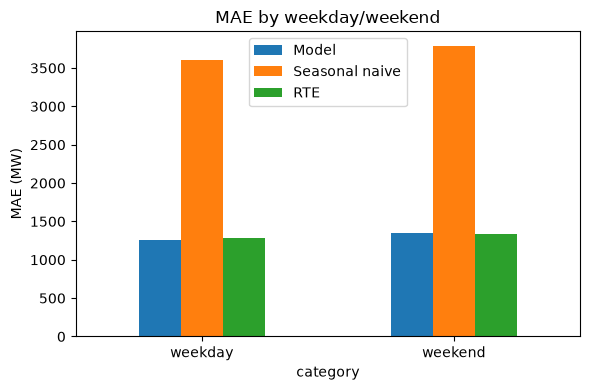

In [5]:
plot_mae_by_category(weekend_table, "MAE by weekday/weekend")

The model is close to RTE in both cases (weekday: 1260 vs. 1281 MW; weekend: 1352 vs. 1342 MW) and both track the same weekday/weekend gap -- weekends are harder to forecast for everyone here, not a model-specific weakness. The naive baseline's relative gap is larger too (6.6% weekday vs. 7.5% weekend MAPE), consistent with weekend demand deviating more from the same-weekday-last-week pattern it relies on.

## Public holidays

In [6]:
holiday_table = error_by_group(df, "is_holiday", labels={True: "holiday", False: "non-holiday"})
holiday_table

,n_hours,model_pred_mae,model_pred_mape,naive_pred_mae,naive_pred_mape,rte_pred_mae,rte_pred_mape
category,,,,,,,
non-holiday,8039,1279.11,2.46,3610.77,6.70,1284.05,2.48
holiday,264,1503.22,3.43,4975.58,11.13,1736.06,3.77


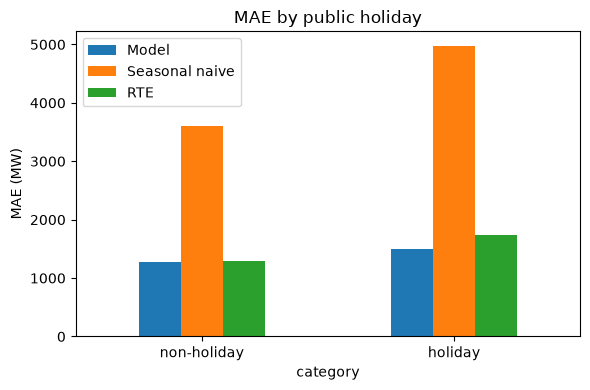

In [7]:
plot_mae_by_category(holiday_table, "MAE by public holiday")

Public holidays are where the model clearly outperforms RTE (1503 vs. 1736 MW MAE) -- the `est_ferie` feature captures the atypical demand pattern that RTE's own forecast seems to track less well here. The naive baseline is by far the worst on holidays (4976 MW MAE, 11.1% MAPE), since "the same hour 168h ago" has no way to know last week wasn't a holiday.

## School holidays (any zone)

In [8]:
school_holiday_table = error_by_group(
    df, "is_school_holiday", labels={True: "school holiday", False: "term time"}
)
school_holiday_table

,n_hours,model_pred_mae,model_pred_mape,naive_pred_mae,naive_pred_mape,rte_pred_mae,rte_pred_mape
category,,,,,,,
term time,4440,1295.39,2.38,3868.23,6.86,1336.80,2.53
school holiday,3863,1275.76,2.63,3408.52,6.82,1254.41,2.52


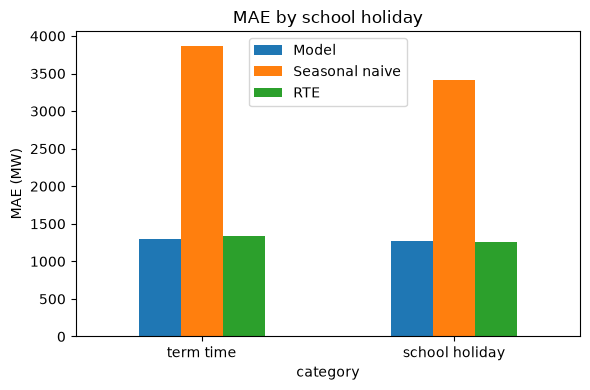

In [9]:
plot_mae_by_category(school_holiday_table, "MAE by school holiday")

School holidays make almost no difference to either forecast (model: 1295 vs. 1276 MW; RTE: 1337 vs. 1254 MW, term time vs. school holiday) -- consistent with school holidays affecting a smaller, more geographically distributed slice of national demand than a full public holiday.

## Cold days (national daily mean temperature <= 5°C)

In [10]:
cold_table = error_by_group(df, "is_cold", labels={True: "cold (<=5C)", False: "not cold"})
cold_table

,n_hours,model_pred_mae,model_pred_mape,naive_pred_mae,naive_pred_mape,rte_pred_mae,rte_pred_mape
category,,,,,,,
not cold,7751,1181.20,2.39,3233.93,6.34,1265.24,2.52
cold (<=5C),552,2759.77,3.99,9547.46,13.88,1764.00,2.58


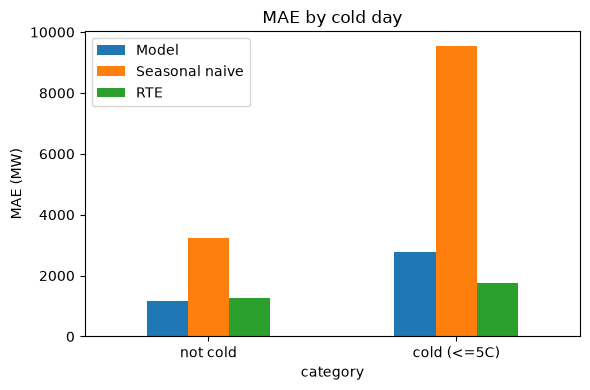

In [11]:
plot_mae_by_category(cold_table, "MAE by cold day")

This is the one category where the model is clearly worse than RTE: 2760 MW MAE on cold days vs. RTE's 1764 MW (vs. 1181 vs. 1265 MW on non-cold days, where the model is slightly ahead of RTE). In relative terms the gap narrows (3.99% vs. 2.58% MAPE) since cold days also carry higher absolute demand, but the model still trails RTE by a wide absolute margin here. This lines up with ADR 0004's noted limitation: only 347 backtest days give just 23 genuinely cold examples to learn a cold-weather demand response from, and RTE likely draws on operational signal (grid-level demand response, a longer historical record) this single-model setup doesn't yet have. A real, honest limitation to flag, not something to paper over.

## Season

In [12]:
season_table = error_by_group(df, "season").reindex(["Winter", "Spring", "Summer", "Autumn"])
season_table

,n_hours,model_pred_mae,model_pred_mape,naive_pred_mae,naive_pred_mape,rte_pred_mae,rte_pred_mape
category,,,,,,,
Winter,2160,1517.54,2.40,5530.95,8.92,1471.06,2.36
Spring,2207,1213.44,2.58,3452.33,7.29,1631.85,3.38
Summer,2206,1109.71,2.49,2336.26,5.15,905.01,2.01
Autumn,1730,1315.58,2.51,3245.56,5.81,1158.58,2.30


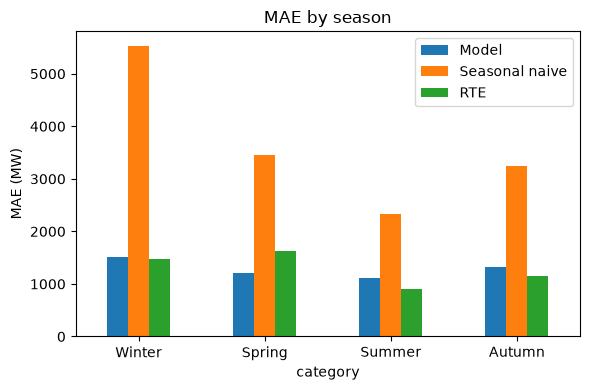

In [13]:
plot_mae_by_category(season_table, "MAE by season")

Performance varies by season more than by any other category here: the model clearly beats RTE in Spring (1213 vs. 1632 MW) and is close in Winter (1518 vs. 1471 MW) and Autumn (1316 vs. 1159 MW), but trails RTE somewhat in Summer (1110 vs. 905 MW) -- though Summer is also where both forecasts' absolute errors are smallest, since summer demand is lower and less volatile than winter. The naive baseline is worst in Winter (5531 MW MAE, 8.9% MAPE), reflecting winter's larger day-to-day demand swings (cold snaps, holidays clustering in December) that a fixed one-week-ago lag can't track.

## Summary

Across categories, the model consistently and substantially beats the seasonal-naive baseline (roughly 60-75% lower MAE depending on category) and is close to or better than RTE's own forecast almost everywhere -- notably beating RTE on public holidays and in Spring. The one clear weakness is cold days, where the model is meaningfully worse than RTE in absolute MW terms. Given the limited backtest history (347 days, only 23 of them genuinely cold), this reads as a real but data-scarcity-driven limitation rather than a fundamental modeling flaw -- a natural target for future work (more historical data, or features/tuning aimed specifically at cold-weather demand), not something to address within this phase.